In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")
from ipywidgets import interact
import ipywidgets as widgets

In [26]:
!pip install -q kagglehub

#Downloading Dataset
dataset_path = kagglehub.dataset_download("mohansacharya/graduate-admissions")

print(f"Dataset downloaded to: {dataset_path}")

Using Colab cache for faster access to the 'graduate-admissions' dataset.
Dataset downloaded to: /kaggle/input/graduate-admissions


In [27]:
import os
for file in os.listdir(dataset_path):
    if file.endswith('.csv'):
        csv_path = os.path.join(dataset_path, file)
        break

df = pd.read_csv(csv_path)

print(f"\nDataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()


Dataset shape: (400, 9)

Columns: ['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA', 'Research', 'Chance of Admit ']


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [28]:
# Cleaning column names
df.columns = df.columns.str.strip().str.replace(' ', '_')
feature_cols = ['GRE_Score', 'TOEFL_Score', 'University_Rating',
                'SOP', 'LOR', 'CGPA', 'Research']

X = df[feature_cols].copy()

print(f"Features for clustering: {list(X.columns)}")
print(f"Feature matrix shape: {X.shape}")

# Standardizing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nScaled data statistics:")
X_scaled_df.describe().round(2)

Features for clustering: ['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA', 'Research']
Feature matrix shape: (400, 7)

Scaled data statistics:


,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.34,-2.54,-1.83,-2.39,-2.73,-3.02,-1.10
25%,-0.77,-0.73,-0.95,-0.89,-0.50,-0.72,-1.10
50%,0.02,-0.07,-0.08,0.10,0.05,0.02,0.91
75%,0.71,0.76,0.80,0.60,0.61,0.78,0.91
max,2.02,2.08,1.67,1.59,1.72,2.22,0.91


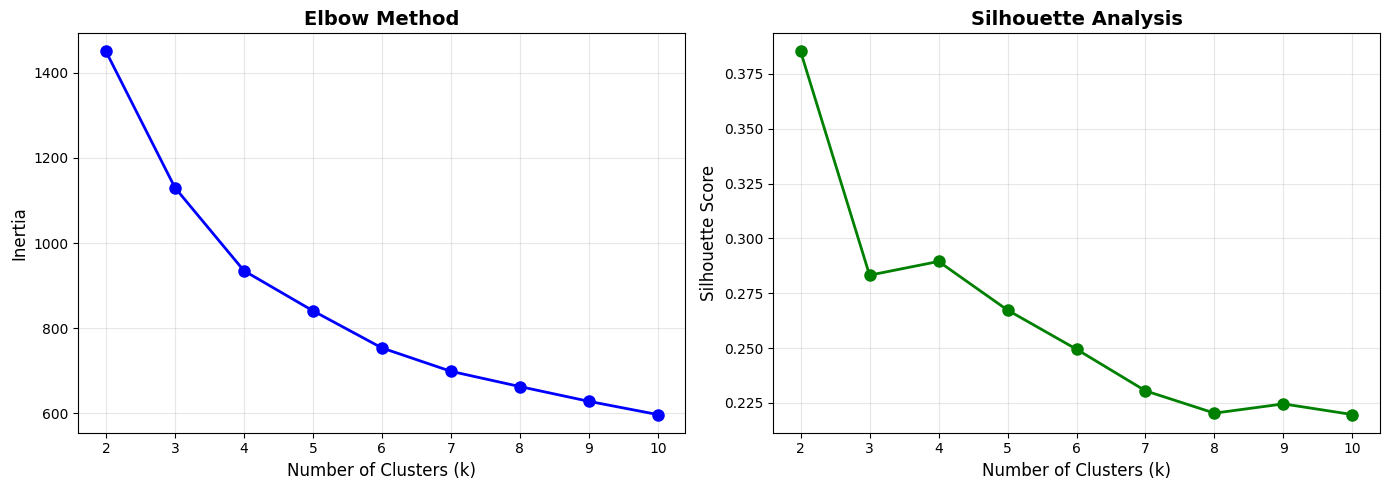

Best k by silhouette: 2 (score: 0.385)
Inertias: {2: 1450, 3: 1130, 4: 935, 5: 841, 6: 754, 7: 699, 8: 663, 9: 628, 10: 597}


In [29]:

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Silhouette Score
ax2.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


best_k = k_range[np.argmax(silhouette_scores)]
print(f"Best k by silhouette: {best_k} (score: {max(silhouette_scores):.3f})")
print(f"Inertias: {dict(zip(k_range, [round(i) for i in inertias]))}")


In [30]:
optimal_k = 2
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Adding cluster labels to original dataframe
df_result = df.copy()
df_result['cluster'] = cluster_labels

df_result.to_csv('applicant_clusters.csv', index=False)
print("applicant_clusters.csv created")

print(f"Cluster distribution:")
print(df_result['cluster'].value_counts().sort_index())

# Displaying cluster centers
cluster_centers_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
centers_df = pd.DataFrame(cluster_centers_original, columns=feature_cols)
centers_df.index = [f'Cluster {i}' for i in range(optimal_k)]
print("\nCluster Centers (Original Scale):")
centers_df.round(2)

applicant_clusters.csv created
Cluster distribution:
cluster
0    175
1    225
Name: count, dtype: int64

Cluster Centers (Original Scale):


,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research
Cluster 0,326.48,112.25,4.01,4.16,4.09,9.10,0.91
Cluster 1,309.28,103.65,2.37,2.81,2.96,8.21,0.26


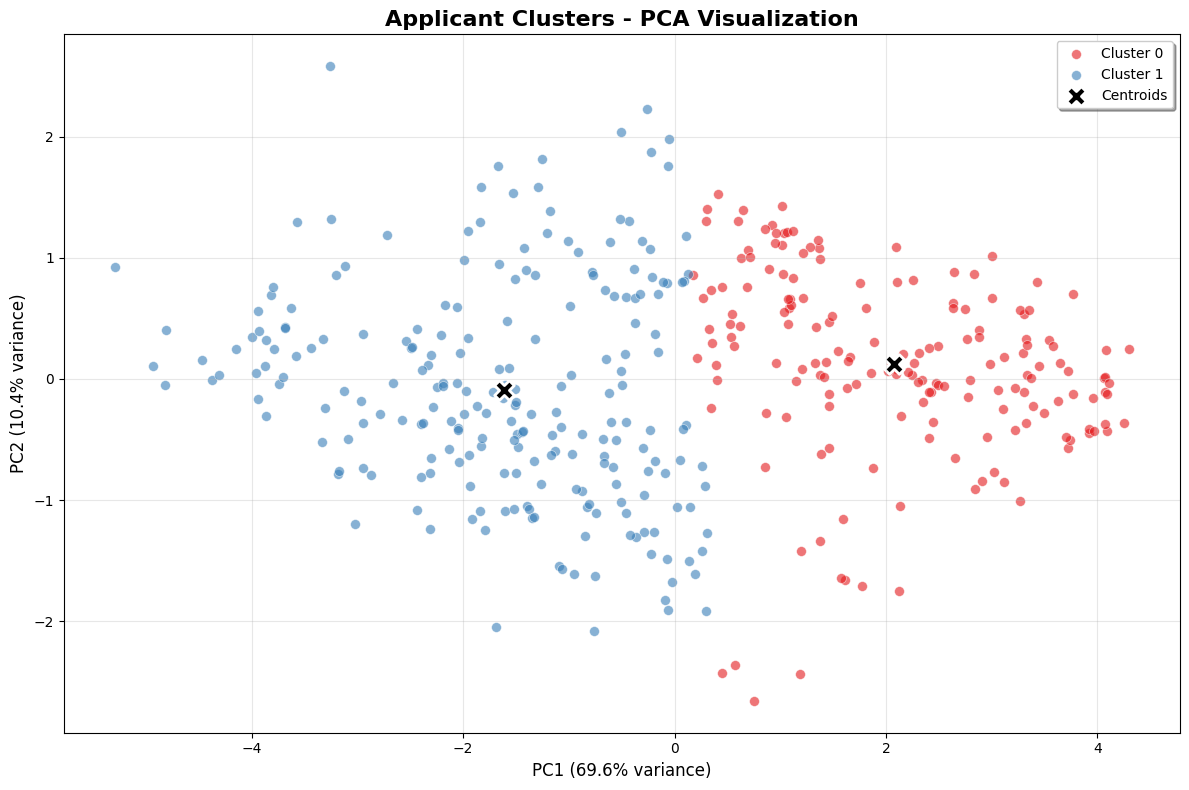

Total variance explained by PC1 & PC2: 80.0%


In [31]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33']

for i in range(optimal_k):
    mask = cluster_labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                alpha=0.6, s=50, edgecolors='w', linewidth=0.5)

# Ploting cluster centers in PCA space
centers_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='black', marker='X', s=200, linewidths=2,
            label='Centroids', edgecolors='w')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title('Applicant Clusters - PCA Visualization', fontsize=16, fontweight='bold')
plt.legend(loc='best', frameon=True, shadow=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total variance explained by PC1 & PC2: {sum(pca.explained_variance_ratio_):.1%}")

In [32]:
# performing cluster Analysis for Graduate Admissions
def analyze_clusters(df, cluster_col='cluster'):
    analysis = {}

    for cluster_id in sorted(df[cluster_col].unique()):
        cluster_data = df[df[cluster_col] == cluster_id]
        analysis[f'Cluster_{cluster_id}'] = {
            'size': len(cluster_data),
            'percentage': f"{len(cluster_data)/len(df)*100:.1f}%",
            'avg_gre': cluster_data['GRE_Score'].mean(),
            'avg_toefl': cluster_data['TOEFL_Score'].mean(),
            'avg_cgpa': cluster_data['CGPA'].mean(),
            'avg_university_rating': cluster_data['University_Rating'].mean(),
            'avg_sop': cluster_data['SOP'].mean(),
            'avg_lor': cluster_data['LOR'].mean(),
            'research_rate': cluster_data['Research'].mean(),
            'admit_chance': cluster_data['Chance_of_Admit'].mean()
        }
    return pd.DataFrame(analysis).T

cluster_analysis = analyze_clusters(df_result)
print("=== CLUSTER PROFILES ===")
print(cluster_analysis.round(2))

cluster_analysis.to_csv('cluster_profiles.csv')
print("cluster_profiles.csv created")

=== CLUSTER PROFILES ===
          size percentage     avg_gre   avg_toefl  avg_cgpa  \
Cluster_0  175      43.8%      326.48  112.245714  9.101143   
Cluster_1  225      56.2%  309.284444  103.648889  8.208311   

          avg_university_rating   avg_sop   avg_lor research_rate admit_chance  
Cluster_0              4.011429  4.162857  4.091429      0.914286     0.840629  
Cluster_1              2.368889  2.806667  2.955556      0.262222     0.633911  
cluster_profiles.csv created


In [33]:
#Generating summary for dataset
def generate_rule_summary(cluster_id, analysis_df):
    row = analysis_df.loc[f'Cluster_{cluster_id}']

    # Determining levels
    gre_level = "High" if row['avg_gre'] > 320 else "Moderate" if row['avg_gre'] > 310 else "Lower"
    cgpa_level = "High" if row['avg_cgpa'] > 9.0 else "Moderate" if row['avg_cgpa'] > 8.0 else "Lower"
    research_focus = "Research-active" if row['research_rate'] > 0.7 else "Mixed" if row['research_rate'] > 0.3 else "Non-research"
    admit_likelihood = "High admit" if row['admit_chance'] > 0.8 else "Moderate admit" if row['admit_chance'] > 0.6 else "Lower admit"

    summary = f"""
    CLUSTER {cluster_id} PROFILE ({int(row['size'])} applicants, {row['percentage']})

    Academic: {gre_level} GRE ({row['avg_gre']:.0f}) | {cgpa_level} CGPA ({row['avg_cgpa']:.2f}) | TOEFL: {row['avg_toefl']:.0f}

    Profile: {research_focus} ({row['research_rate']:.0%} have research) | LOR: {row['avg_lor']:.1f} | SOP: {row['avg_sop']:.1f}

    Outcome: {admit_likelihood} probability ({row['admit_chance']:.0%})

    Strategy: """

    if gre_level == "High" and cgpa_level == "High" and row['research_rate'] > 0.8:
        summary += "Premium candidates - offer scholarships & fast-track admission."
    elif cgpa_level == "Lower" and row['research_rate'] > 0.5:
        summary += "Experience-focused - highlight portfolio & project opportunities."
    elif row['admit_chance'] > 0.8:
        summary += "Likely admits - streamline process, minimal intervention needed."
    elif row['admit_chance'] < 0.6:
        summary += "At-risk segment - provide prep resources & conditional pathways."
    else:
        summary += "Standard outreach - emphasize program fit & career outcomes."

    return summary

print("=" * 70)
for i in range(optimal_k):
    print(generate_rule_summary(i, cluster_analysis))
    print("=" * 70)


    CLUSTER 0 PROFILE (175 applicants, 43.8%)

    Academic: High GRE (326) | High CGPA (9.10) | TOEFL: 112

    Profile: Research-active (91% have research) | LOR: 4.1 | SOP: 4.2

    Outcome: High admit probability (84%)

    Strategy: Premium candidates - offer scholarships & fast-track admission.

    CLUSTER 1 PROFILE (225 applicants, 56.2%)

    Academic: Lower GRE (309) | Moderate CGPA (8.21) | TOEFL: 104

    Profile: Non-research (26% have research) | LOR: 3.0 | SOP: 2.8

    Outcome: Moderate admit probability (63%)

    Strategy: Standard outreach - emphasize program fit & career outcomes.


In [34]:
print("Current columns in df_result:", list(df_result.columns))
print("Current columns in df:", list(df.columns))

# Standardizing the target column name
if 'Chance_of_Admit ' in df_result.columns:
    df_result['Chance_of_Admit'] = df_result['Chance_of_Admit ']
elif 'Chance of Admit ' in df.columns:
    df_result['Chance_of_Admit'] = df['Chance of Admit ']

#cleaning columns
df_result.columns = df_result.columns.str.strip().str.replace(' ', '_')
print("Fixed columns:", list(df_result.columns))

Current columns in df_result: ['Serial_No.', 'GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance_of_Admit', 'cluster']
Current columns in df: ['Serial_No.', 'GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance_of_Admit']
Fixed columns: ['Serial_No.', 'GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance_of_Admit', 'cluster']


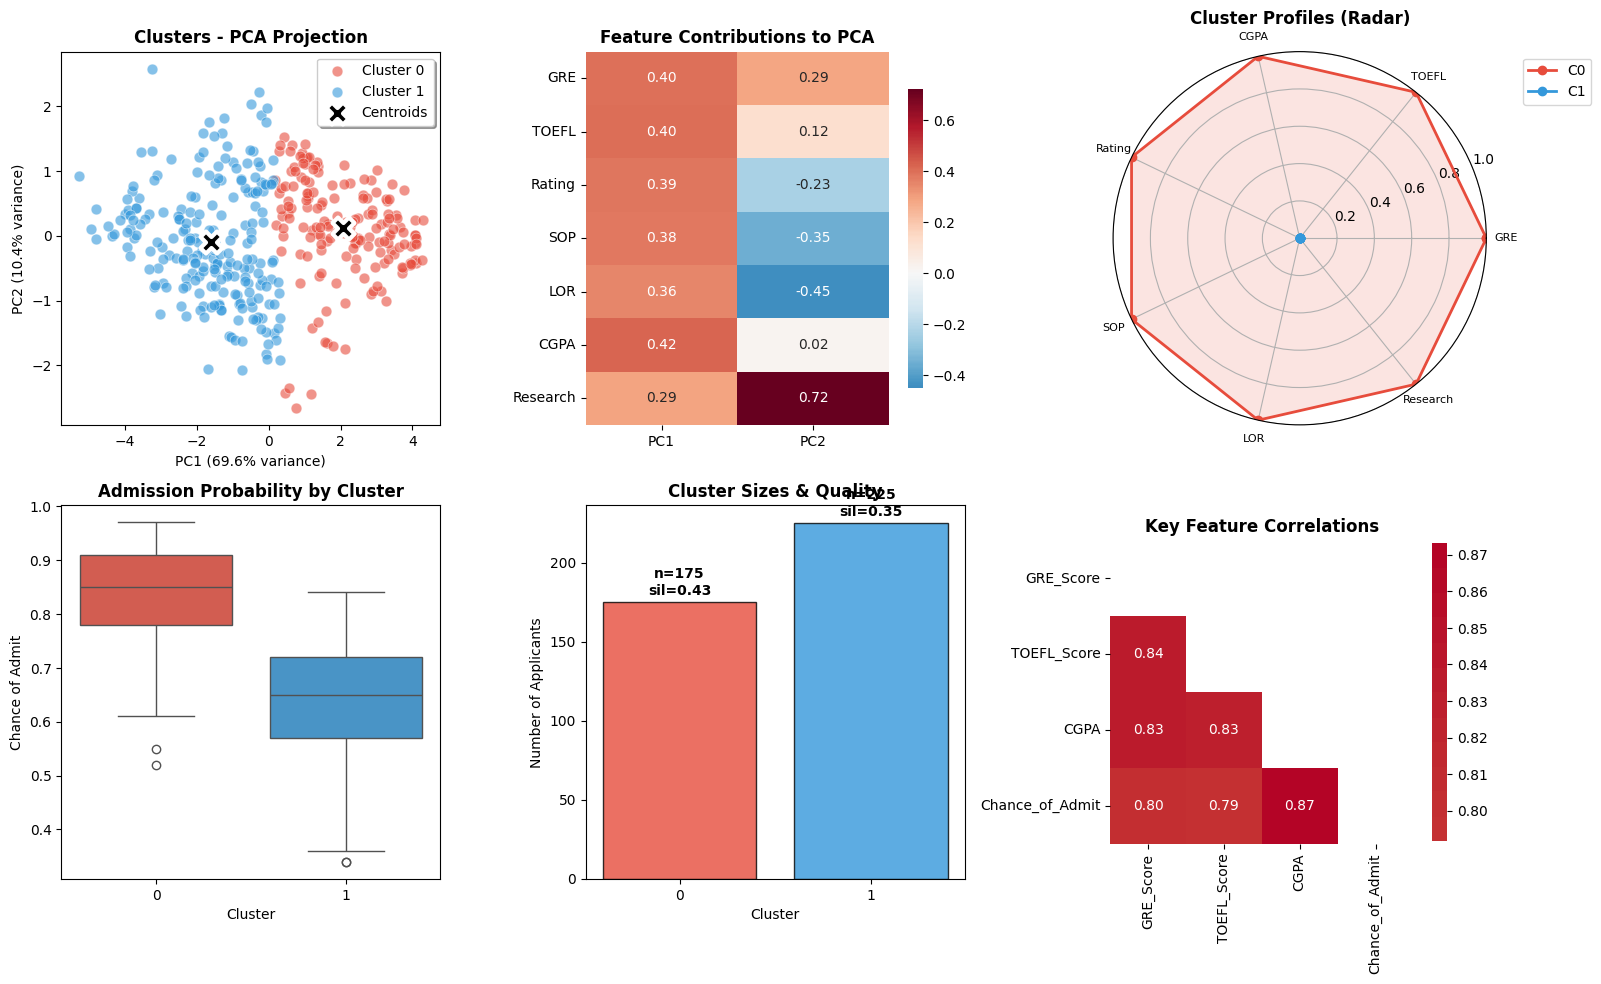

Dashboard saved as 'clustering_dashboard.png'


In [35]:
# creating quality dashboard
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import silhouette_samples

# Verifying prerequisites exist
assert 'df_result' in globals(), "df_result not found - run Phase 5 first"
assert 'X_pca' in globals(), "X_pca not found - run PCA first"
assert 'cluster_labels' in globals(), "cluster_labels not found - run Phase 5 first"

plt.style.use('default')
fig = plt.figure(figsize=(16, 10))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

# 1. PCA Scatter
ax1 = plt.subplot(2, 3, 1)
for i in range(optimal_k):
    mask = cluster_labels == i
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                alpha=0.6, s=60, edgecolors='w', linewidth=0.5)
centers_pca = pca.transform(kmeans_final.cluster_centers_)
ax1.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='black', marker='X', s=250, linewidths=3,
            edgecolors='w', label='Centroids', zorder=5)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax1.set_title('Clusters - PCA Projection', fontweight='bold')
ax1.legend(frameon=True, fancybox=True, shadow=True)

# 2. Feature Importance
ax2 = plt.subplot(2, 3, 2)
feature_names = ['GRE', 'TOEFL', 'Rating', 'SOP', 'LOR', 'CGPA', 'Research']
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_names
)
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', ax=ax2, cbar_kws={'shrink': 0.8})
ax2.set_title('Feature Contributions to PCA', fontweight='bold')

# 3. Cluster Profiles
ax3 = plt.subplot(2, 3, 3, projection='polar')
categories = ['GRE', 'TOEFL', 'CGPA', 'Rating', 'SOP', 'LOR', 'Research']
N = len(categories)

# Normalizing centers for radar (0-1 scale)
centers = kmeans_final.cluster_centers_
centers_norm = (centers - centers.min(axis=0)) / (centers.max(axis=0) - centers.min(axis=0))

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for i in range(optimal_k):
    values = centers_norm[i].tolist()
    values += values[:1]
    ax3.plot(angles, values, 'o-', linewidth=2, label=f'C{i}', color=colors[i])
    ax3.fill(angles, values, alpha=0.15, color=colors[i])

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(categories, size=8)
ax3.set_ylim(0, 1)
ax3.set_title('Cluster Profiles (Radar)', fontweight='bold', pad=20)
ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

# 4. Admission Probability by Cluster
ax4 = plt.subplot(2, 3, 4)
sns.boxplot(data=df_result, x='cluster', y='Chance_of_Admit',
            palette=colors[:optimal_k], ax=ax4)
ax4.set_title('Admission Probability by Cluster', fontweight='bold')
ax4.set_xlabel('Cluster')
ax4.set_ylabel('Chance of Admit')

# 5. Cluster Sizes with Silhouette
ax5 = plt.subplot(2, 3, 5)
cluster_sizes = df_result['cluster'].value_counts().sort_index()
silhouette_vals = silhouette_samples(X_scaled, cluster_labels)
avg_sil = [silhouette_vals[cluster_labels == i].mean() for i in range(optimal_k)]

bars = ax5.bar(range(optimal_k), cluster_sizes,
               color=colors[:optimal_k], alpha=0.8, edgecolor='black')
ax5.set_xlabel('Cluster')
ax5.set_ylabel('Number of Applicants')
ax5.set_title('Cluster Sizes & Quality', fontweight='bold')
ax5.set_xticks(range(optimal_k))

for i, (bar, sil) in enumerate(zip(bars, avg_sil)):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 3,
             f'n={int(height)}\nsil={sil:.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 6. Featuring Correlation Heatmap
ax6 = plt.subplot(2, 3, 6)
corr_cols = ['GRE_Score', 'TOEFL_Score', 'CGPA', 'Chance_of_Admit']
corr_matrix = df_result[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm',
            center=0, square=True, ax=ax6, fmt='.2f',
            cbar_kws={'shrink': 0.8})
ax6.set_title('Key Feature Correlations', fontweight='bold')

plt.tight_layout()
plt.savefig('clustering_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print("Dashboard saved as 'clustering_dashboard.png'")

In [36]:
files.download('clustering_dashboard.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
# Verification stage
assert 'df_result' in globals(), "df_result not found"

def explore_cluster(cluster_id):
    """Safe interactive explorer"""
    from IPython.display import clear_output
    clear_output(wait=True)

    cluster_data = df_result[df_result['cluster'] == cluster_id]

    print(f"{'='*60}")
    print(f" CLUSTER {cluster_id} ANALYSIS ({len(cluster_data)} applicants)")
    print(f"{'='*60}")

    # Stats
    stats = {
        'Avg GRE': cluster_data['GRE_Score'].mean(),
        'Avg TOEFL': cluster_data['TOEFL_Score'].mean(),
        'Avg CGPA': cluster_data['CGPA'].mean(),
        'Research %': cluster_data['Research'].mean() * 100,
        'Avg Admit': cluster_data['Chance_of_Admit'].mean() * 100
    }

    for key, val in stats.items():
        bar = '█' * int(val / 10)
        print(f"{key:15}: {val:6.1f} {bar}")


    print(f"\n STRATEGY:")
    if stats['Avg GRE'] > 320 and stats['Avg CGPA'] > 9.0:
        print("→ VIP Segment: Offer scholarships, fast-track admission")
    elif stats['Research %'] > 60:
        print("→ Research Track: Emphasize labs, thesis opportunities")
    elif stats['Avg Admit'] < 60:
        print("→ Support Program: Prep courses, conditional pathways")
    else:
        print("→ Standard Outreach: Program fit, career outcomes")

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))

    axes[0].hist(cluster_data['CGPA'], bins=8, color=colors[cluster_id],
                 alpha=0.7, edgecolor='black')
    axes[0].set_title(f'Cluster {cluster_id} - CGPA Distribution')
    axes[0].set_xlabel('CGPA')

    research_counts = cluster_data['Research'].value_counts()
    axes[1].pie(research_counts, labels=['No Research', 'Research'],
                autopct='%1.0f%%', colors=['lightcoral', 'lightgreen'])
    axes[1].set_title('Research Experience')

    plt.tight_layout()
    plt.show()

# Create slider
interact(explore_cluster,
         cluster_id=widgets.IntSlider(min=0, max=optimal_k-1, step=1,
                                      value=0, description='Cluster:'))

interactive(children=(IntSlider(value=0, description='Cluster:', max=1), Output()), _dom_classes=('widget-inte…

<function __main__.explore_cluster(cluster_id)>

MODEL EFFECTIVENESS DEMONSTRATION

 CLUSTERING QUALITY:
  • Silhouette Score:  0.385
    Interpretation: Fair structure found
  • Calinski-Harabasz: 370.6 (higher = better)
  • Davies-Bouldin:    0.969 (<1.0 is good)

 TARGETING EFFECTIVENESS:
  Cluster 0: 84% admit rate | 175 apps | HIGH priority
  Cluster 1: 63% admit rate | 225 apps | MEDIUM priority


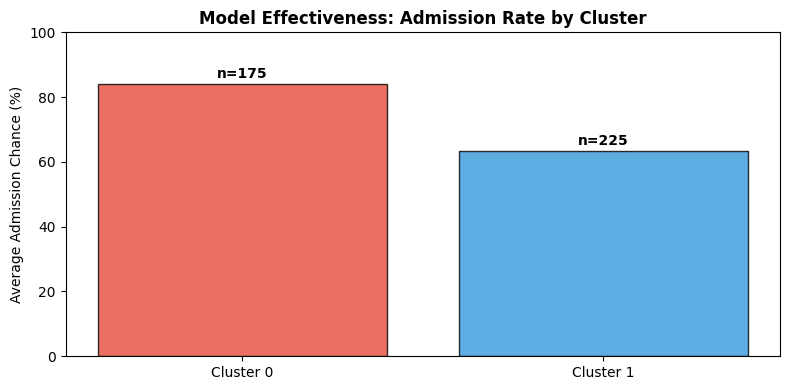


 CONCLUSION: Model identified 2 distinct segments enabling targeted outreach.


In [38]:
# Cell: Effectiveness Report (ISOLATED)
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Verify
assert 'X_scaled' in globals(), "X_scaled not found"
assert 'cluster_labels' in globals(), "cluster_labels not found"

print("=" * 70)
print("MODEL EFFECTIVENESS DEMONSTRATION")
print("=" * 70)

# 1. Quality Metrics
silhouette_avg = silhouette_score(X_scaled, cluster_labels)
calinski = calinski_harabasz_score(X_scaled, cluster_labels)
davies_bouldin = davies_bouldin_score(X_scaled, cluster_labels)

print(f"\n CLUSTERING QUALITY:")
print(f"  • Silhouette Score:  {silhouette_avg:.3f}")
print(f"    Interpretation: ", end="")
if silhouette_avg > 0.5:
    print("Good separation")
elif silhouette_avg > 0.25:
    print("Fair structure found")
else:
    print("Weak structure (expected with k=2)")

print(f"  • Calinski-Harabasz: {calinski:.1f} (higher = better)")
print(f"  • Davies-Bouldin:    {davies_bouldin:.3f} (<1.0 is good)")

# 2. Business Impact
print(f"\n TARGETING EFFECTIVENESS:")
admit_stats = df_result.groupby('cluster')['Chance_of_Admit'].agg(['mean', 'count'])
for idx, row in admit_stats.iterrows():
    potential = 'HIGH' if row['mean'] > 0.8 else 'MEDIUM' if row['mean'] > 0.6 else 'LOW'
    print(f"  Cluster {idx}: {row['mean']:.0%} admit rate | {int(row['count'])} apps | {potential} priority")

# 3. Simple bar chart
fig, ax = plt.subplots(figsize=(8, 4))
clusters = [f'Cluster {i}' for i in range(optimal_k)]
admit_rates = [admit_stats.loc[i, 'mean'] * 100 for i in range(optimal_k)]
sizes = [admit_stats.loc[i, 'count'] for i in range(optimal_k)]

bars = ax.bar(clusters, admit_rates, color=colors[:optimal_k], alpha=0.8, edgecolor='black')
ax.set_ylabel('Average Admission Chance (%)')
ax.set_title('Model Effectiveness: Admission Rate by Cluster', fontweight='bold')
ax.set_ylim(0, 100)

# Add size labels
for bar, size in zip(bars, sizes):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'n={int(size)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n CONCLUSION: Model identified {optimal_k} distinct segments enabling targeted outreach.")

In [39]:
# Demonstration of how to use the model
new_applicant = pd.DataFrame([{
    'GRE_Score': 330,
    'TOEFL_Score': 115,
    'University_Rating': 4,
    'SOP': 4.5,
    'LOR': 4.5,
    'CGPA': 9.5,
    'Research': 1
}])

print("New Applicant:")
print(new_applicant)

# Step 1: Scale using your trained scaler
new_scaled = scaler.transform(new_applicant)

# Step 2: Predict cluster
predicted_cluster = kmeans_final.predict(new_scaled)[0]

print(f"\n Predicted Cluster: {predicted_cluster}")

# Step 3: Get recommendation
similar_applicants = df_result[df_result['cluster'] == predicted_cluster]
avg_admit = similar_applicants['Chance_of_Admit'].mean()

if avg_admit > 0.8:
    action = " VIP: Fast-track and scholarship offer"
elif avg_admit > 0.6:
    action = " STANDARD: Regular process"
else:
    action = " SUPPORT: Additional prep resources"

print(f"\n Recommended Action: {action}")
print(f"   (Based on {len(similar_applicants)} similar past applicants)")

New Applicant:
   GRE_Score  TOEFL_Score  University_Rating  SOP  LOR  CGPA  Research
0        330          115                  4  4.5  4.5   9.5         1

 Predicted Cluster: 0

 Recommended Action:  VIP: Fast-track and scholarship offer
   (Based on 175 similar past applicants)


In [40]:
from google.colab import files

# Downloading  all 3 deliverables
files.download('applicant_clusters.csv')
files.download('cluster_profiles.csv')
files.download('clustering_dashboard.png')

print("All 3 files downloading to your computer...")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All 3 files downloading to your computer...
